In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
input_path = "preprocessed_diabetes_data.csv"
cleaned_path = pd.read_csv(input_path)

In [10]:
print("Cleaned Data Preview:")
print(cleaned_path.head())

Cleaned Data Preview:
  Experimental Strategy Condition            Tissue Cell Type  Gender    Age  \
0            Expression       T1D  Peripheral blood     PBMCs  Female   1-10   
1            Expression       T1D  Peripheral blood     PBMCs    Male   1-10   
2            Expression       T1D  Peripheral blood     PBMCs    Male   1-10   
3            Expression       T1D  Peripheral blood     PBMCs    Male  11-20   
4            Expression       T1D  Peripheral blood     PBMCs    Male   1-10   

  Ethnicity  
0     White  
1   Unknown  
2     Black  
3     White  
4   Unknown  


In [12]:
df = pd.read_csv('preprocessed_diabetes_data.csv')
df.fillna('Unknown', inplace=True)
diabetes_data = df[df['Condition'].str.strip().str.contains('T1D', case=False, na=False)]
columns_to_drop = ['GSE', 'GPL', 'Sample']
diabetes_data = diabetes_data.drop(columns=[col for col in columns_to_drop if col in diabetes_data.columns])
print(diabetes_data.to_string())
X = cleaned_path.drop(columns=['Condition'])
y = cleaned_path['Condition']

   Experimental Strategy Condition            Tissue Cell Type  Gender    Age Ethnicity
0             Expression       T1D  Peripheral blood     PBMCs  Female   1-10     White
1             Expression       T1D  Peripheral blood     PBMCs    Male   1-10   Unknown
2             Expression       T1D  Peripheral blood     PBMCs    Male   1-10     Black
3             Expression       T1D  Peripheral blood     PBMCs    Male  11-20     White
4             Expression       T1D  Peripheral blood     PBMCs    Male   1-10   Unknown
5             Expression       T1D  Peripheral blood     PBMCs    Male   1-10   Unknown
6             Expression       T1D  Peripheral blood     PBMCs  Female   1-10     White
7             Expression       T1D  Peripheral blood     PBMCs  Female   1-10     White
8             Expression       T1D  Peripheral blood     PBMCs  Female  11-20     White
9             Expression       T1D  Peripheral blood     PBMCs    Male  11-20     White
10            Expression       T

# Assistant
Let me explain the selected code line by line:

1. `df = pd.read_csv('preprocessed_diabetes_data.csv')` - Reads a CSV file named 'preprocessed_diabetes_data.csv' into a pandas DataFrame.

2. `df.fillna('Unknown', inplace=True)` - Fills any missing values (NaN) in the DataFrame with the string 'Unknown'. The `inplace=True` means it modifies the DataFrame directly.

3. `diabetes_data = df[df['Condition'].str.strip().str.contains('T1D', case=False, na=False)]` - Creates a new DataFrame containing only rows where the 'Condition' column contains 'T1D' (case-insensitive). The `strip()` removes leading/trailing whitespace.

4. `columns_to_drop = ['GSE', 'GPL', 'Sample']` - Creates a list of column names to be removed.

5. `diabetes_data = diabetes_data.drop(columns=[col for col in columns_to_drop if col in diabetes_data.columns])` - Removes specified columns from the DataFrame, but only if they exist.

6. `print(diabetes_data.to_string())` - Prints the entire DataFrame as a string without truncation.

7. `X = cleaned_path.drop(columns=['Condition'])` - Creates feature matrix X by removing the 'Condition' column.

8. `y = cleaned_path['Condition']` - Creates target variable y containing only the 'Condition' column.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
print(f"\nTraining Set Size: {X_train.shape}")
print(f"Testing Set Size: {X_test.shape}")


Training Set Size: (16, 6)
Testing Set Size: (4, 6)


# Assistant
The selected code performs a train-test split on the dataset and prints the sizes of the training and testing sets. Here's a step-by-step explanation:

1. `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` - This line uses the `train_test_split` function from the `sklearn.model_selection` module to split the features (`X`) and target labels (`y`) into training and testing sets.
   - `X` is the feature set, while `y` is the target variable.
   - `test_size=0.2` specifies that 20% of the data should be allocated to the testing set, while the remaining 80% will be used for training.
   - `random_state=42` ensures that the split is reproducible; using the same random state will yield the same split every time the code is run.
   - `stratify=y` ensures that the split maintains the same proportion of classes in both the training and testing sets as in the original dataset.

2. `print(f"\nTraining Set Size: {X_train.shape}")` - This line prints the size (shape) of the training feature set `X_train`. The `shape` attribute returns a tuple representing the dimensions of the array (number of samples, number of features).

3. `print(f"Testing Set Size: {X_test.shape}")` - This line prints the size (shape) of the testing feature set `X_test`, similar to the previous line. 

Overall, this code snippet is used to prepare the data for training and evaluation of a machine learning model while providing information about the sizes of the resulting datasets.

In [16]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train', index=False)
y_test.to_csv('y_test', index=False)
print("Train-Test Split Completed. Datasets saved.")

Train-Test Split Completed. Datasets saved.


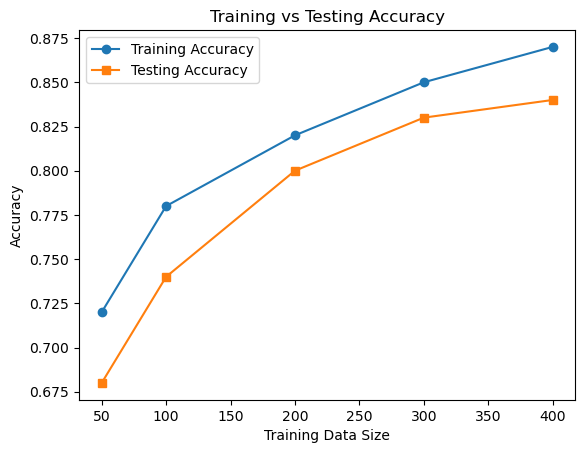

In [2]:
import matplotlib.pyplot as plt

train_sizes = [50, 100, 200, 300, 400]
train_scores = [0.72, 0.78, 0.82, 0.85, 0.87]
test_scores = [0.68, 0.74, 0.80, 0.83, 0.84]

plt.plot(train_sizes, train_scores, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_scores, marker='s', label='Testing Accuracy')
plt.xlabel('Training Data Size')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Testing Accuracy')
plt.show()